# Step 1 — Image Preprocessing (OpenCV)

Prepare receipt for Tesseract OCR: upscale if small, greyscale, optional sharpening, global threshold or greyscale.

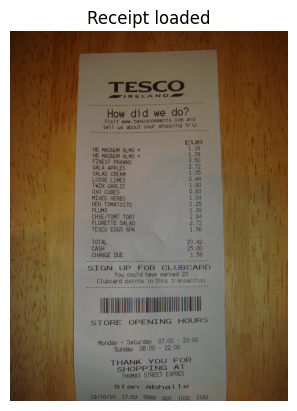

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_PATH = "Data/tesco_receipt.png"
img = cv2.imread(IMAGE_PATH)
if img is not None:
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Receipt loaded")
    plt.axis("off")
    plt.show()

In [23]:
MIN_DPI_PX = 750  # ~300 DPI for typical receipt

def load_image(path):
    """Load image, return RGB."""
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def upscale_if_small(img, min_dim=MIN_DPI_PX):
    """Upscale if width or height below min (Tesseract needs ~300 DPI)."""
    h, w = img.shape[:2]
    if w >= min_dim and h >= min_dim:
        return img
    scale = max(min_dim / w, min_dim / h)
    new_w, new_h = int(w * scale), int(h * scale)
    return cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_CUBIC)

def to_greyscale(img):
    """Convert to greyscale (always)."""
    if len(img.shape) == 3:
        return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return img

def sharpen_if_soft(grey, sharpness_thresh=100):
    """Light sharpen only if text looks soft (low Laplacian variance)."""
    var = cv2.Laplacian(grey, cv2.CV_64F).var()
    if var >= sharpness_thresh:
        return grey
    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)
    return np.clip(cv2.filter2D(grey, -1, kernel), 0, 255).astype(np.uint8)

def global_threshold(grey):
    """Simple Otsu threshold. Use grey directly if prefer greyscale for OCR."""
    _, thresh = cv2.threshold(grey, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return thresh

In [24]:
# Pipeline: upscale → greyscale → sharpen if soft → threshold (or use grey for OCR)
USE_THRESHOLD = True  # False = send greyscale directly to OCR
img_original = load_image(IMAGE_PATH)
img_scaled = upscale_if_small(img_original)
grey = to_greyscale(img_scaled)
grey = sharpen_if_soft(grey)
img_cleaned = global_threshold(grey) if USE_THRESHOLD else grey

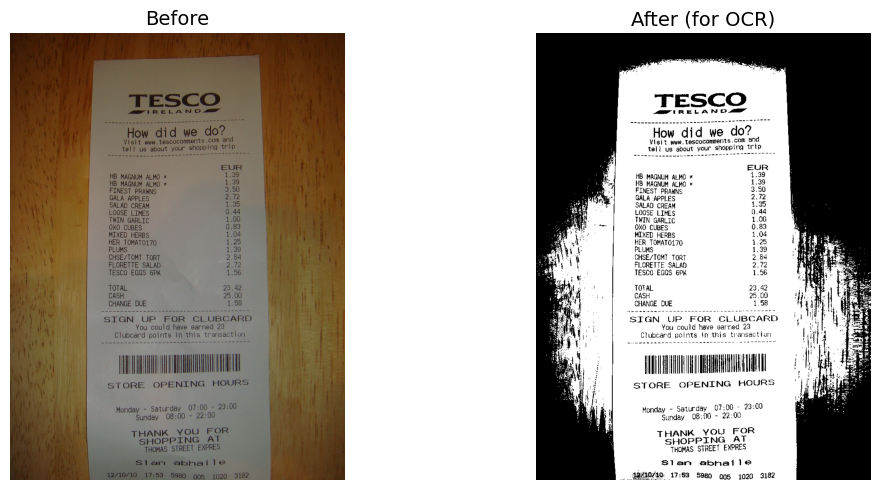

In [25]:
# Before and After
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_original)
axes[0].set_title("Before", fontsize=14)
axes[0].axis("off")
axes[1].imshow(img_cleaned, cmap="gray")
axes[1].set_title("After (for OCR)", fontsize=14)
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
cv2.imwrite("receipt_cleaned.png", img_cleaned)


In [26]:
import pytesseract

# img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

print("Running OCR on uncleaned Image")
print(pytesseract.image_to_string(img))

Running OCR on uncleaned Image
TESCO

IRELAND ar

How did we do?

Visit www. tescoconments.com and
tell us about your shoppi ip

HB MAGNUM ALMO * -
HB MAGNUM ALMO = 1.99
FINEST PRAWNS 3
GALA APPLES 2
SALAD CREAM t
LOOSE LIMES 0
TWIN GARLIC 1
OXO_CUBES 0.
MIXED HERBS 1
HER TOMATO170 i
PLUMS i

2

2

1

CHSE/TOMT TORT

FLORETTE SALAD

TESCO EGGS 6PK 56 ee t

TOTAL 23.42 i

CASH yt +

CHANGE DUE 1.58 " i
SIGN UP FOR CLUBCARD |} j |

You could have earned 23
Clubcard points in this transacti

Uo eNnomonert
NESRRBSRANS

MN A

STORE OPENING HOURS

Monday - Saturday 07:00 = 23:00
Sunday 08:00 - 22:00

THANK YOU FOR
SHOPPING AT
THOMAS STREET EXPRES

abhaile
(10/10 17 BO 005 1020 3182




In [27]:
print("Running OCR on cleaned Image")
raw_ocr_text = pytesseract.image_to_string(img_cleaned)
print(raw_ocr_text)

Running OCR on cleaned Image
TESCO

Ar REL AN Dar

How did we do?

Visit www. tescocomments.com and
tell us about your shoppl ip

HB MAGNUM ALMO © 1.
HB MAGNUM ALK © 139
FINEST PRAWNS 3.50
GALA APPLES 2.72
SALAD CREAN 1.35
; LOOSE CIMES 0.44
—_ TWIN GARL TC 1.00
f OXO_CUBES 0.83
. NIXED HERES 104
HER TOMATOL70 4.25
PLUMS 1S
CHSE/TOMT ToRT 234 :
FLORETTE SALAD 3:72
TESCO EGGS 6K ra

; TOTAL. 23.43
‘ cASH 34
CHANGE, DUE

You could have earried 23
Clubcard points in this transaction

| in

STORE OPENING HOURS

Monday - Saturday 07:00 - 23:00
Sunday 08:00 - 22:00

THANK YOU FOR
SHOPPING AT
THOMAS STREET EXPRES

Slan abnaile
(40: 17:53 5980 oo5 1020 3182




## Extracting data from OCR using LLM

### Main objectives:
    1. What did the user spend 
    2. Where and when did they spend it?

In [28]:
test_raw_ocr_text = """
TESC0 STORES LTD
CLUBCARD PRICE

WHL MLK 4PT              1.29
CHDR MTRE 400G            2.50
STRWB YGT MLTPK x2        3.00
CLUBCARD SAVING           -0.80
FAIRY LQD ORGNL 900ML     3.50

---------
SUBTOTAL                  9.49
VAT                       0.47
TOTAL                    £9.96

CONTACTLESS
THANK YOU FOR SHOPPING
"""

system_message = """
You are a receipt parser for a family budget advisor application.
You will receive raw OCR text from a receipt scan.
Extract the data and return ONLY a valid JSON object.
No explanation. No markdown. No code blocks. Just the JSON.

Rules:
- Clean up obvious OCR errors (e.g. "TESC0" → "Tesco")
- Expand abbreviations where confident (e.g. "WHL MLK" → "Whole Milk")
- If you cannot determine a value with confidence, use null
- Prices must be numbers not strings (1.29 not "1.29")
- Promotions and savings should be captured as positive numbers
- Date format must be YYYY-MM-DD

Return this exact structure:
{
  "merchant": {
    "name": string or null,
    "type": string or null
  },
  "transaction": {
    "date": string or null,
    "total": number or null,
    "subtotal": number or null,
    "tax": number or null,
    "currency": string
  },
  "items": [
    {
      "raw_description": string,
      "clean_description": string or null,
      "quantity": number,
      "unit_price": number or null,
      "line_total": number or null,
      "on_promotion": boolean,
      "promotion_saving": number or null
    }
  ],
  "savings": {
    "total_promotions": number,
    "total_saved": number
  }
}
"""

user_message = f"""
Here is the raw OCR text from a receipt scan:

{raw_ocr_text}
"""

In [29]:
import os
from dotenv import load_dotenv
import openai

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if OPENAI_API_KEY is None:
    raise ValueError("OPENAI_API_KEY is not set")

client = openai.OpenAI(api_key=OPENAI_API_KEY)



In [30]:
response = client.chat.completions.create(
    model="gpt-4o-mini",
    temperature=0,           # 0 = deterministic, no creativity, same output every run
    messages=[
        {"role": "system", "content": system_message},
        {"role": "user",   "content": user_message}
    ]
)

# The raw string response from the LLM
raw_response = response.choices[0].message.content
print("--- RAW LLM RESPONSE ---")
print(raw_response)

# Use parse model for structured output
# https://developers.openai.com/api/docs/guides/structured-outputs

--- RAW LLM RESPONSE ---
{
  "merchant": {
    "name": "Tesco",
    "type": "Grocery"
  },
  "transaction": {
    "date": null,
    "total": 23.43,
    "subtotal": null,
    "tax": null,
    "currency": "GBP"
  },
  "items": [
    {
      "raw_description": "HB MAGNUM ALMO © 1.",
      "clean_description": "HB Magnum Almond",
      "quantity": 1,
      "unit_price": null,
      "line_total": null,
      "on_promotion": false,
      "promotion_saving": null
    },
    {
      "raw_description": "HB MAGNUM ALK © 139",
      "clean_description": "HB Magnum Milk",
      "quantity": 1,
      "unit_price": null,
      "line_total": null,
      "on_promotion": false,
      "promotion_saving": null
    },
    {
      "raw_description": "FINEST PRAWNS 3.50",
      "clean_description": "Finest Prawns",
      "quantity": 1,
      "unit_price": 3.50,
      "line_total": 3.50,
      "on_promotion": false,
      "promotion_saving": null
    },
    {
      "raw_description": "GALA APPLES 2.72",
     

In [31]:
import json
import re

def parse_llm_response(raw_response: str) -> dict:
    """
    Safely parse the LLM response string into a Python dict.
    Handles the case where the LLM wraps its JSON in markdown code fences
    despite being told not to.
    """
    # Strip markdown code fences if present (e.g. ```json ... ```)
    cleaned = re.sub(r'^```(?:json)?\s*', '', raw_response.strip())
    cleaned = re.sub(r'\s*```$', '', cleaned)

    try:
        return json.loads(cleaned)
    except json.JSONDecodeError as e:
        raise ValueError(f"LLM returned invalid JSON: {e}\n\nRaw response was:\n{raw_response}")

receipt_data = parse_llm_response(raw_response)

print("--- PARSED RECEIPT ---")
print(json.dumps(receipt_data, indent=2))

--- PARSED RECEIPT ---
{
  "merchant": {
    "name": "Tesco",
    "type": "Grocery"
  },
  "transaction": {
    "date": null,
    "total": 23.43,
    "subtotal": null,
    "tax": null,
    "currency": "GBP"
  },
  "items": [
    {
      "raw_description": "HB MAGNUM ALMO \u00a9 1.",
      "clean_description": "HB Magnum Almond",
      "quantity": 1,
      "unit_price": null,
      "line_total": null,
      "on_promotion": false,
      "promotion_saving": null
    },
    {
      "raw_description": "HB MAGNUM ALK \u00a9 139",
      "clean_description": "HB Magnum Milk",
      "quantity": 1,
      "unit_price": null,
      "line_total": null,
      "on_promotion": false,
      "promotion_saving": null
    },
    {
      "raw_description": "FINEST PRAWNS 3.50",
      "clean_description": "Finest Prawns",
      "quantity": 1,
      "unit_price": 3.5,
      "line_total": 3.5,
      "on_promotion": false,
      "promotion_saving": null
    },
    {
      "raw_description": "GALA APPLES 2.72",

In [32]:
print("=== RECEIPT SUMMARY ===")
print(f"Merchant:   {receipt_data['merchant']['name']}")
print(f"Date:       {receipt_data['transaction']['date']}")
print(f"Total:      {receipt_data['transaction']['currency']} {receipt_data['transaction']['total']}")
print(f"Items:      {len(receipt_data['items'])}")
print(f"Total saved: {receipt_data['savings']['total_saved']}")

print("\n=== LINE ITEMS ===")
for item in receipt_data['items']:
    flag = "🚩" if item['on_promotion'] else "  "
    print(f"{flag} {item['clean_description']:<35} £{item['line_total']}")

=== RECEIPT SUMMARY ===
Merchant:   Tesco
Date:       None
Total:      GBP 23.43
Items:      14
Total saved: 0

=== LINE ITEMS ===
   HB Magnum Almond                    £None
   HB Magnum Milk                      £None
   Finest Prawns                       £3.5
   Gala Apples                         £2.72
   Salad Cream                         £1.35
   Loose Limes                         £0.44
   Twin Garlic                         £1.0
   Oxo Cubes                           £0.83
   Mixed Herbs                         £None
   Heritage Tomatoes                   £4.25
   Plums                               £None
   Cheese/Tomato Tortilla              £None
   Florette Salad                      £3.72
   Tesco Eggs                          £None


## Use image to text vision Open AI model

In [33]:
import base64

def encode_image(image_path: str) -> str:
    """Read image file and return base64 encoded string."""
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")
    
base64_image = encode_image(IMAGE_PATH)

ext = os.path.splitext(IMAGE_PATH)[1].lower()
mime_type = {
    ".jpg":  "image/jpeg",
    ".jpeg": "image/jpeg",
    ".png":  "image/png",
    ".webp": "image/webp"
}.get(ext, "image/jpeg")

print(f"Image encoded — format: {mime_type}")


Image encoded — format: image/png


In [34]:
response = client.responses.create(
    model="gpt-4.1",
    input=[
        {
            "role": "user",
            "content": [
                { "type": "input_text", "text": "what's in this image?" },
                {
                    "type": "input_image",
                    "image_url": f"data:{mime_type};base64,{base64_image}",
                },
            ],
        }
    ],
)

print(response.output_text)


This image is a receipt from Tesco Ireland. Here are the main details visible:

**Header:**
- Tesco Ireland logo
- A message asking "How did we do?" with a website link for customer feedback (www.tescocomments.com).

**Purchased Items (with their prices in EUR):**
- HB Magnum Almo x2 (€1.39 each)
- Finest Prawns (€3.50)
- Gala Apples (€2.12)
- Salad Cream (€1.35)
- Loose Limes (€0.18)
- Twin Garlic (€1.03)
- Oxo Cubes (€1.04)
- Mixed Herbs (€0.94)
- Her Tomat0170 (€1.79)
- Plums (€1.30)
- Chest/Tom Tort (€2.84)
- Florette Salad (€2.72)
- Tesco Eggs 6pk (€1.56)

**Totals:**
- Total: €23.42
- Cash given: €25.00
- Change due: €1.58

**Other details:**
- Encouragement to "Sign up for Clubcard" (points could have been earned).
- Store opening hours: 
  - Mon-Sat: 07:00 - 23:00
  - Sun: 08:00 - 22:00
- Thank you message for shopping at "Thomas Street Express."
- Receipt timestamp: 12 October 2010, 17:53 (along with some store/transaction numbers).

**Visuals:**
- The receipt is printed on wh